**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

**Data Cleaning**

In [2]:
# Load Dataset
df = pd.read_csv("retail_sales_dataset.csv")

In [3]:
# Display first rows
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
# Display last rows
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [5]:
# Dataset shape
df.shape

(1000, 9)

In [6]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [8]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [9]:
# Check missing values
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [10]:
# Check duplicate records
df.duplicated().sum()

np.int64(0)

In [11]:
# Remove duplicates
df = df.drop_duplicates()

In [53]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

In [12]:
# Convert date column
df["Date"] = pd.to_datetime(df["Date"])

In [13]:
# Check datatype
df.dtypes

,0
Transaction ID,int64
Date,datetime64[ns]
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


In [54]:
# Extract date features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

In [16]:
# Descriptive statistics
# Mean
df.mean(numeric_only=True)

,0
Transaction ID,500.500
Age,41.392
Quantity,2.514
Price per Unit,179.890
Total Amount,456.000
Year,2023.002
Day,15.310


In [17]:
# Median
df.median(numeric_only=True)

,0
Transaction ID,500.5
Age,42.0
Quantity,3.0
Price per Unit,50.0
Total Amount,135.0
Year,2023.0
Day,15.0


In [18]:
# Mode
df.mode().head(1)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Day,Weekday
0,1,2023-05-16,CUST001,Female,43.0,Clothing,4.0,50.0,50.0,2023.0,May,5.0,Tuesday


In [19]:
# Standard Deviation
df.std(numeric_only=True)

,0
Transaction ID,288.819436
Age,13.681430
Quantity,1.132734
Price per Unit,189.681356
Total Amount,559.997632
Year,0.044699
Day,8.871674


Univariate Analysis

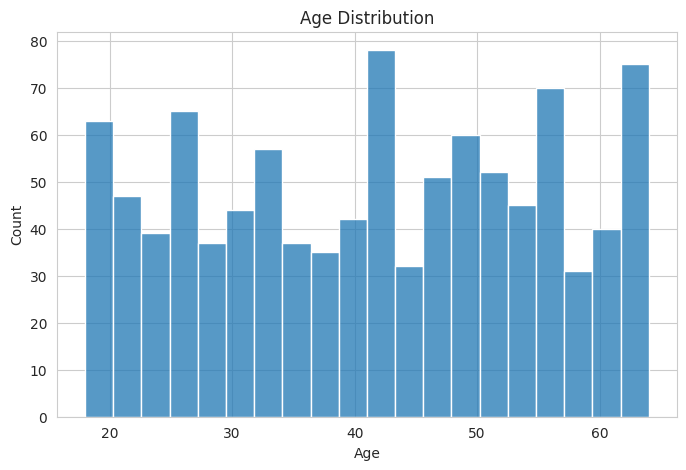

In [23]:
# Age distribuition
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

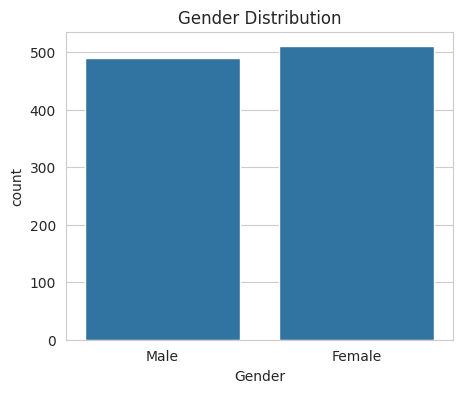

In [22]:
# Gender count
plt.figure(figsize=(5,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

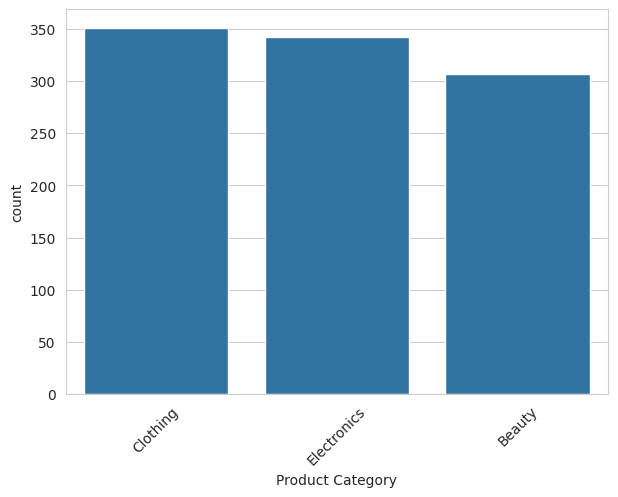

In [24]:
# Product Category Count
plt.figure(figsize=(7,5))
sns.countplot(data=df,
              x="Product Category",
              order=df["Product Category"].value_counts().index)
plt.xticks(rotation=45)
plt.show()

In [25]:
# Sales Analysis
print("Total Sales =", df["Total Amount"].sum())

Total Sales = 456000


In [26]:
# Average Sale
print(df["Total Amount"].mean())

456.0


In [27]:
# Maximum Sale
print(df["Total Amount"].max())

2000


In [28]:
# Minimum Sale
print(df["Total Amount"].min())

25


Time Series Analysis

In [29]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()

In [30]:
monthly_sales

,Total Amount
Month,
April,33870
August,36960
December,44690
February,44060
January,36980
July,35465
June,36715
March,28990
May,53150


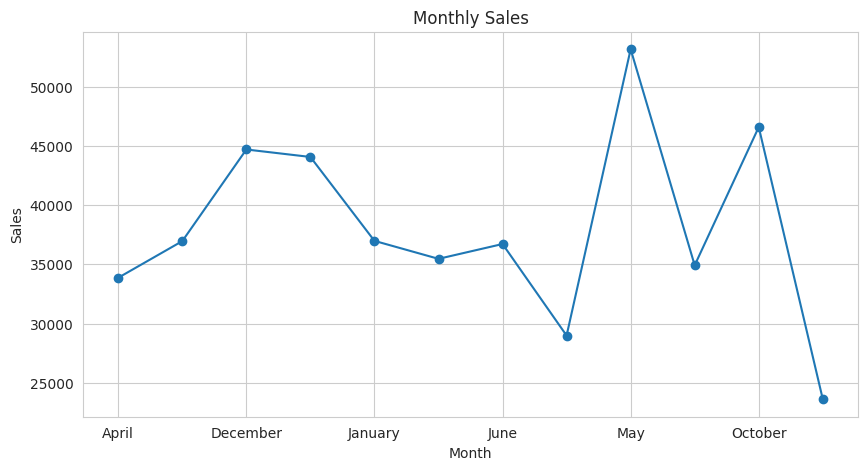

In [31]:
plt.figure(figsize=(10,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales")
plt.ylabel("Sales")
plt.show()

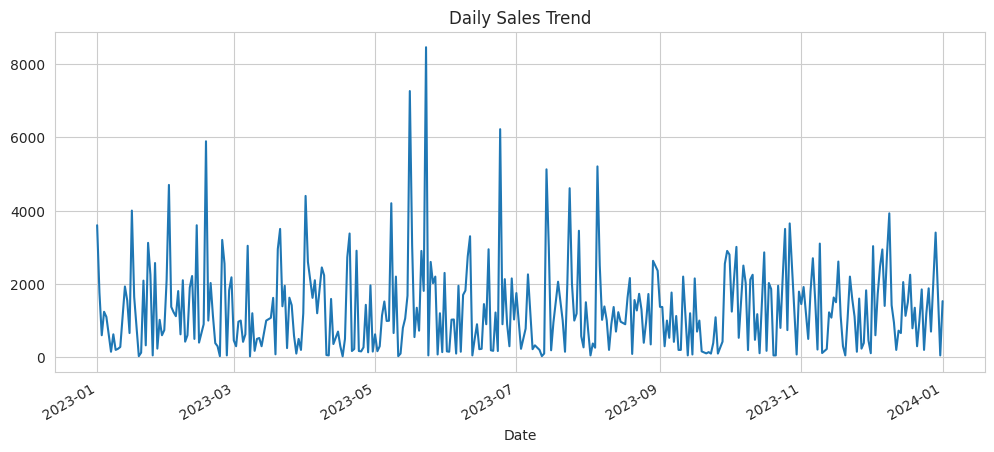

In [33]:
# Daily Sales Trend
daily_sales = df.groupby("Date")["Total Amount"].sum()
plt.figure(figsize=(12,5))
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.show()

In [34]:
# Customer Analysis
gender_sales = df.groupby("Gender")["Total Amount"].sum()
gender_sales

,Total Amount
Gender,
Female,232840
Male,223160


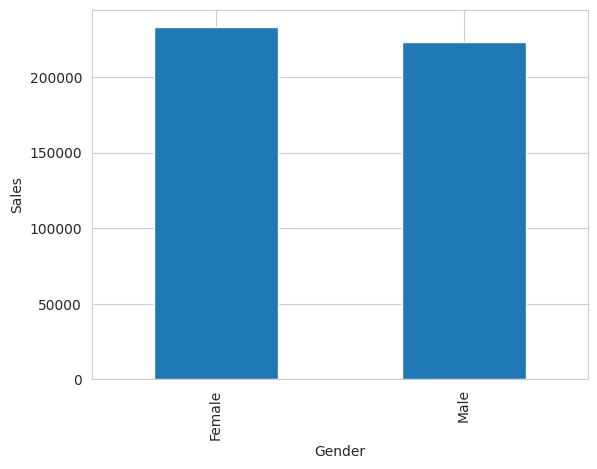

In [35]:
gender_sales.plot(kind="bar")
plt.ylabel("Sales")
plt.show()

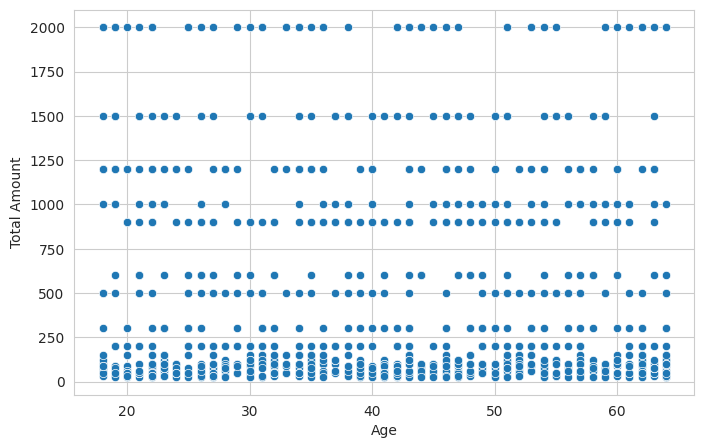

In [36]:
# Age wise spending
plt.figure(figsize=(8,5))
sns.scatterplot(x="Age",
                y="Total Amount",
                data=df)
plt.show()

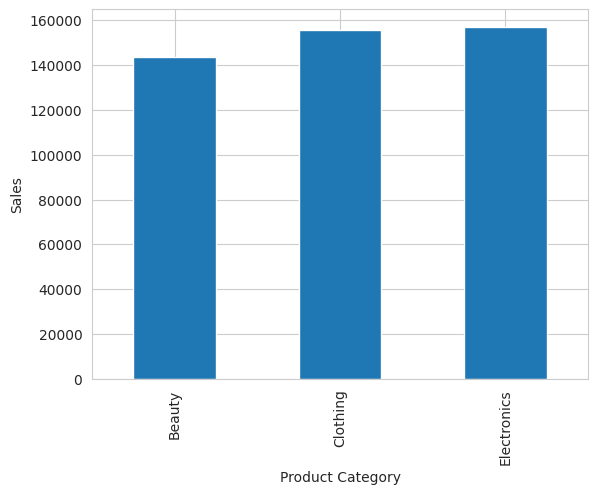

In [40]:
# Product Analysis
category_sales = df.groupby("Product Category")["Total Amount"].sum()
category_sales.plot(kind="bar")
plt.ylabel("Sales")
plt.show()

In [41]:
# Average quantity sold
df.groupby("Product Category")["Quantity"].mean()

,Quantity
Product Category,
Beauty,2.511401
Clothing,2.547009
Electronics,2.482456


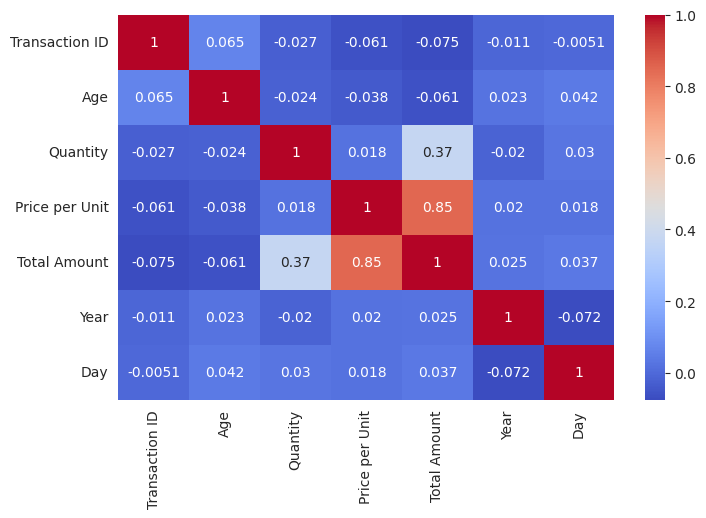

In [42]:
# Relationship Analysis
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,5))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")
plt.show()

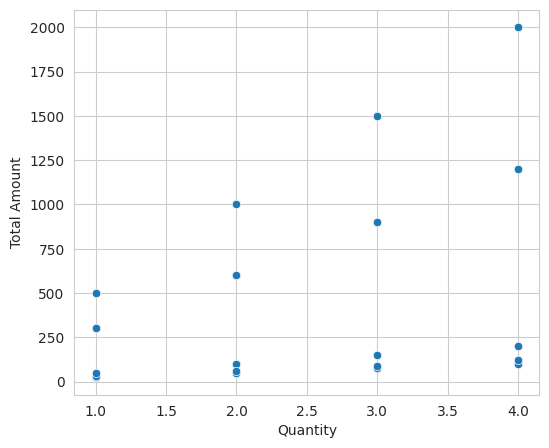

In [43]:
# Quantity vs Total Amount
plt.figure(figsize=(6,5))
sns.scatterplot(data=df,
                x="Quantity",
                y="Total Amount")
plt.show()

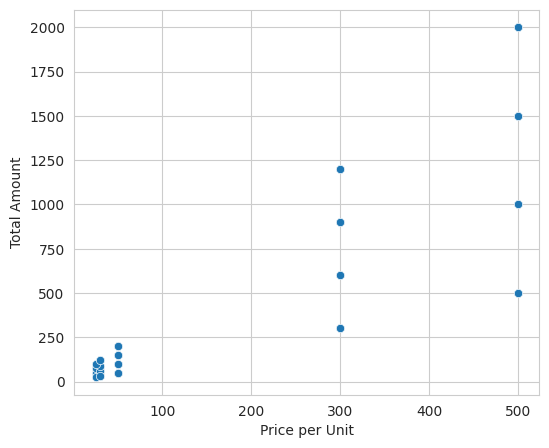

In [45]:
# Price vs total amount
plt.figure(figsize=(6,5))
sns.scatterplot(data=df,
                x="Price per Unit",
                y="Total Amount")
plt.show()

Outlier Detection

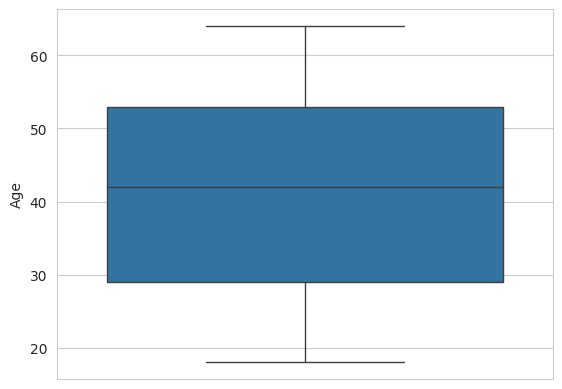

In [46]:
# age
sns.boxplot(y=df["Age"])
plt.show()

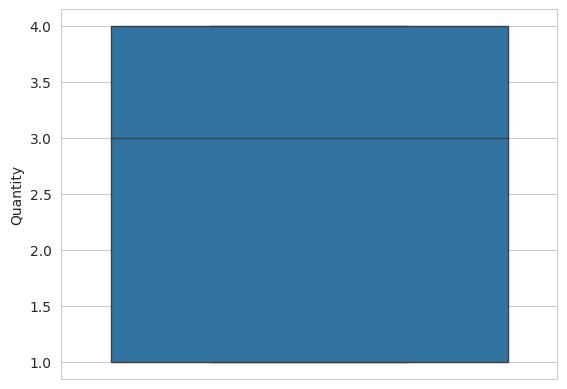

In [47]:
# quantity
sns.boxplot(y=df["Quantity"])
plt.show()

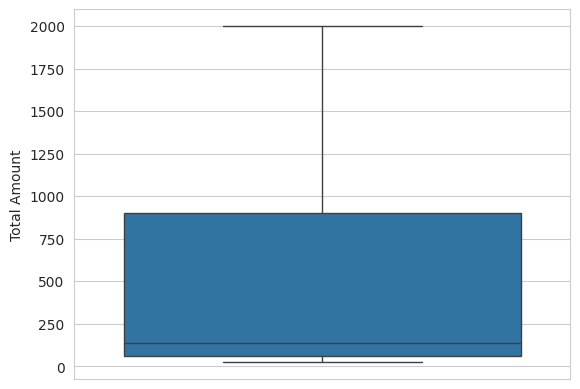

In [48]:
# Total Amount
sns.boxplot(y=df["Total Amount"])
plt.show()

Top Customers

In [49]:
top_customers = df.groupby("Customer ID")["Total Amount"].sum().sort_values(ascending=False)
top_customers.head(10)

,Total Amount
Customer ID,
CUST015,2000
CUST412,2000
CUST970,2000
CUST547,2000
CUST281,2000
CUST416,2000
CUST420,2000
CUST927,2000
CUST447,2000


In [50]:
# Top Product Categories
top_products = df.groupby("Product Category")["Total Amount"].sum()
top_products.sort_values(ascending=False)

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


In [51]:
# Pivot Table
pivot = pd.pivot_table(df,
                       values="Total Amount",
                       index="Gender",
                       columns="Product Category",
                       aggfunc="sum")
pivot

Product Category,Beauty,Clothing,Electronics
Gender,,,
Female,74830,81275,76735
Male,68685,74305,80170


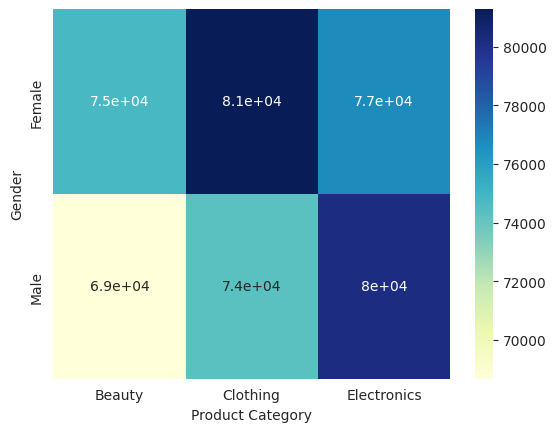

In [52]:
# Heatmap
sns.heatmap(pivot,
            annot=True,
            cmap="YlGnBu")
plt.show()